In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [48]:
housing=pd.read_csv("housing.csv")
print("housing shape",housing.shape)

housing shape (20640, 10)


In [49]:
housing.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Q(1):the project objective is preparation the data for training the machine learning model for the housing

In [50]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Q(2):the number of columns and the Dtype of each column and the number of non_Null value for each Column

In [51]:
missing=housing.isna().sum() # === missing=housing.isnull().sum()

print(missing)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [52]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Q(3): there are some missing values between the columns
Q(4):housing.dropna() or housing.fillna()

In [53]:
duplicated_rows=housing[housing.duplicated()]
print("duplicated rows shape",duplicated_rows.shape)

duplicated rows shape (0, 10)


Q(5): all the columns has some duplicated values

In [54]:
ocean_proximity=housing['ocean_proximity'].unique()
print(ocean_proximity)
housing['ocean_proximity'].value_counts()

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Q(6):housing.groupby(['ocean_proximity']).mean(numeric_only=True)


In [55]:
cat_feature=housing.select_dtypes(include=[object]).columns
print(cat_feature)

Index(['ocean_proximity'], dtype='object')


In [56]:
#Q(7):
num_feature=housing.select_dtypes(include=[np.number]).columns
print(num_feature)


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


Q(8): the InterQuartile Range is a measure of statistical dispersion, or how spread out the values in your data are

In [57]:
def outlier_detection(df,varibale):
    q1=df[varibale].quantile(0.25)
    q3=df[varibale].quantile(0.75)
    iqr=q3-q1


    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    print(f'Q1={q1:.3f},Q3={q3:.3f}, IQR={iqr:.3f},lower={lower:.3f},upper={upper:.3f}')
    outliers=[]
    for index, x in enumerate(df[varibale]):
        if x<=lower or x>=upper:
            outliers.append(index)
    return outliers

outliers=outlier_detection(housing,'total_bedrooms')
print( 'Number of outliers =',len(outliers))

Q1=296.000,Q3=647.000, IQR=351.000,lower=-230.500,upper=1173.500
Number of outliers = 1271


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

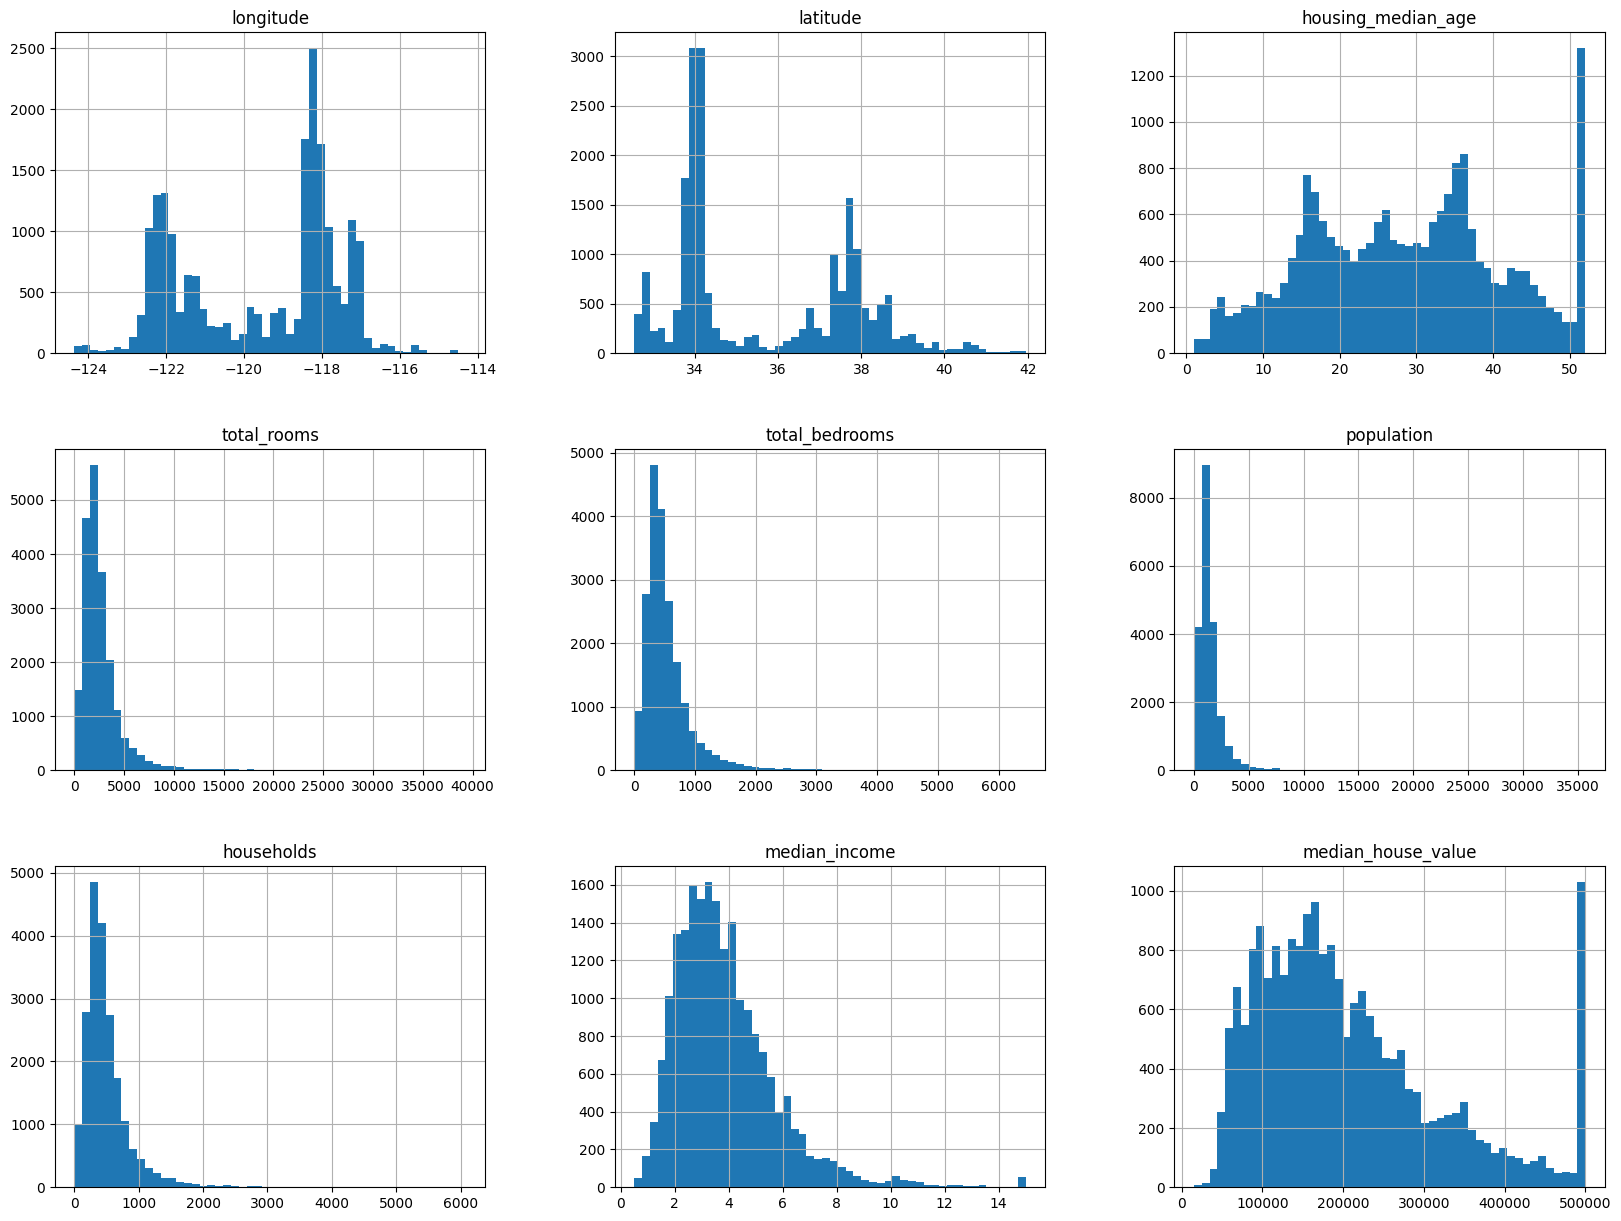

In [58]:
housing.hist(bins=50,figsize=(20,15))


Q(9):the distrubition it is unormal for total_rooms, total_bedrooms, population, and households
q(10): we should apply Normalization and Deal with Outliers

In [59]:
num_feature=housing.select_dtypes(include=[np.number]).columns
skewness=housing[num_feature].skew
print(skewness)

<bound method DataFrame.skew of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  

In [60]:
kurtosis=housing[num_feature].kurtosis()
print(kurtosis)

longitude             -1.330152
latitude              -1.117760
housing_median_age    -0.800629
total_rooms           32.630927
total_bedrooms        21.985575
population            73.553116
households            22.057988
median_income          4.952524
median_house_value     0.327870
dtype: float64


<Axes: xlabel='longitude', ylabel='latitude'>

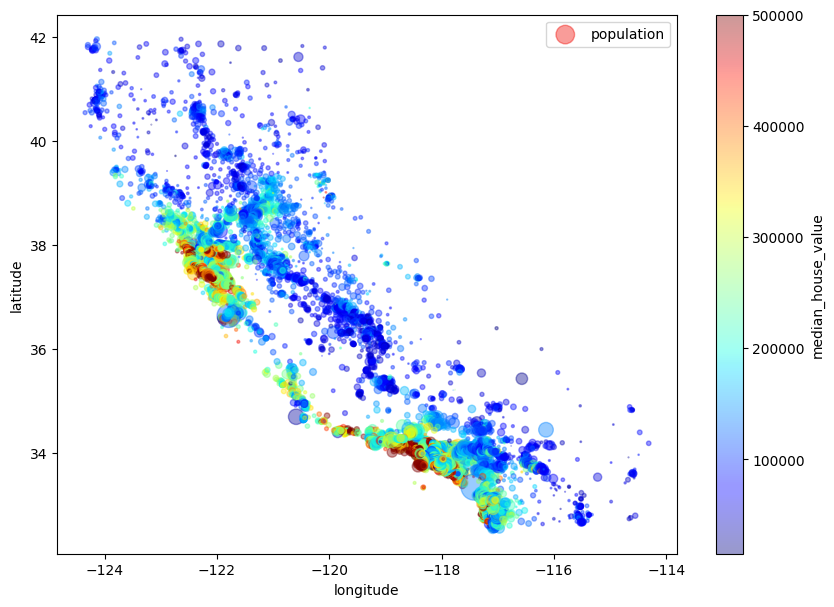

In [61]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,s=housing['population']/100.,label='population',figsize=(10,7),c="median_house_value",cmap=plt.get_cmap(name="jet"),colorbar=True)

Q(11): by observing the figure we conclude that the housses with more altitude and less longitude are less populated and cheaper , and the houses with more longitude and less latitude are more populated and more expensive

In [62]:
housing[["population","median_house_value"]].corr()

,population,median_house_value
population,1.00000,-0.02465
median_house_value,-0.02465,1.00000


Q(12): the corrolation between population and median_house_value it is weak 

<Axes: >

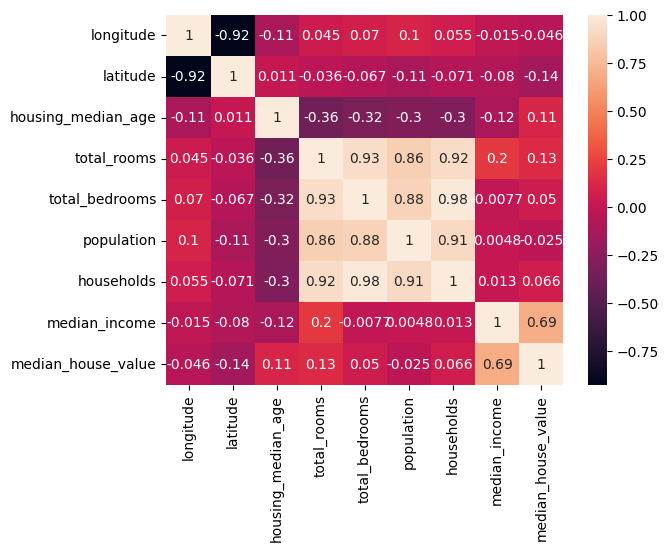

In [63]:
corr_matrix=housing.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True)

In [64]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

Q(13):
👉👉👉 1.more then the median_income increase the median_house_value increase (and transversale )
👉👉👉 2.more then the latitude increase the median_house_value decrease (and transversale )
👉👉👉 3.median_income is the more feature that effect median_house_value
👉👉👉 4.median_income , total_rooms , housing_median_age ,households  ,total_bedrooms have positive correlation (they are value go withe median_house_value in the same way)
👉👉👉 5.population , longitude , latitude,households  have negative correlation (they are value go withe median_house_value in the opposite way)

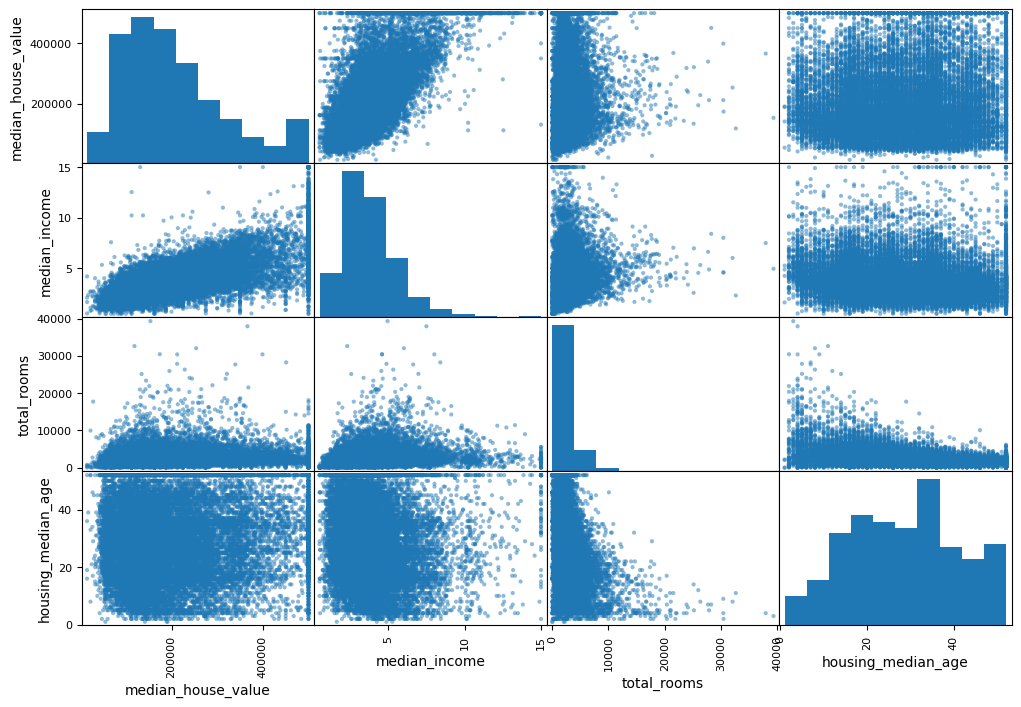

In [65]:
attributes=["median_house_value","median_income","total_rooms","housing_median_age"]
pd.plotting.scatter_matrix(frame=housing[attributes],figsize=(12,8))
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

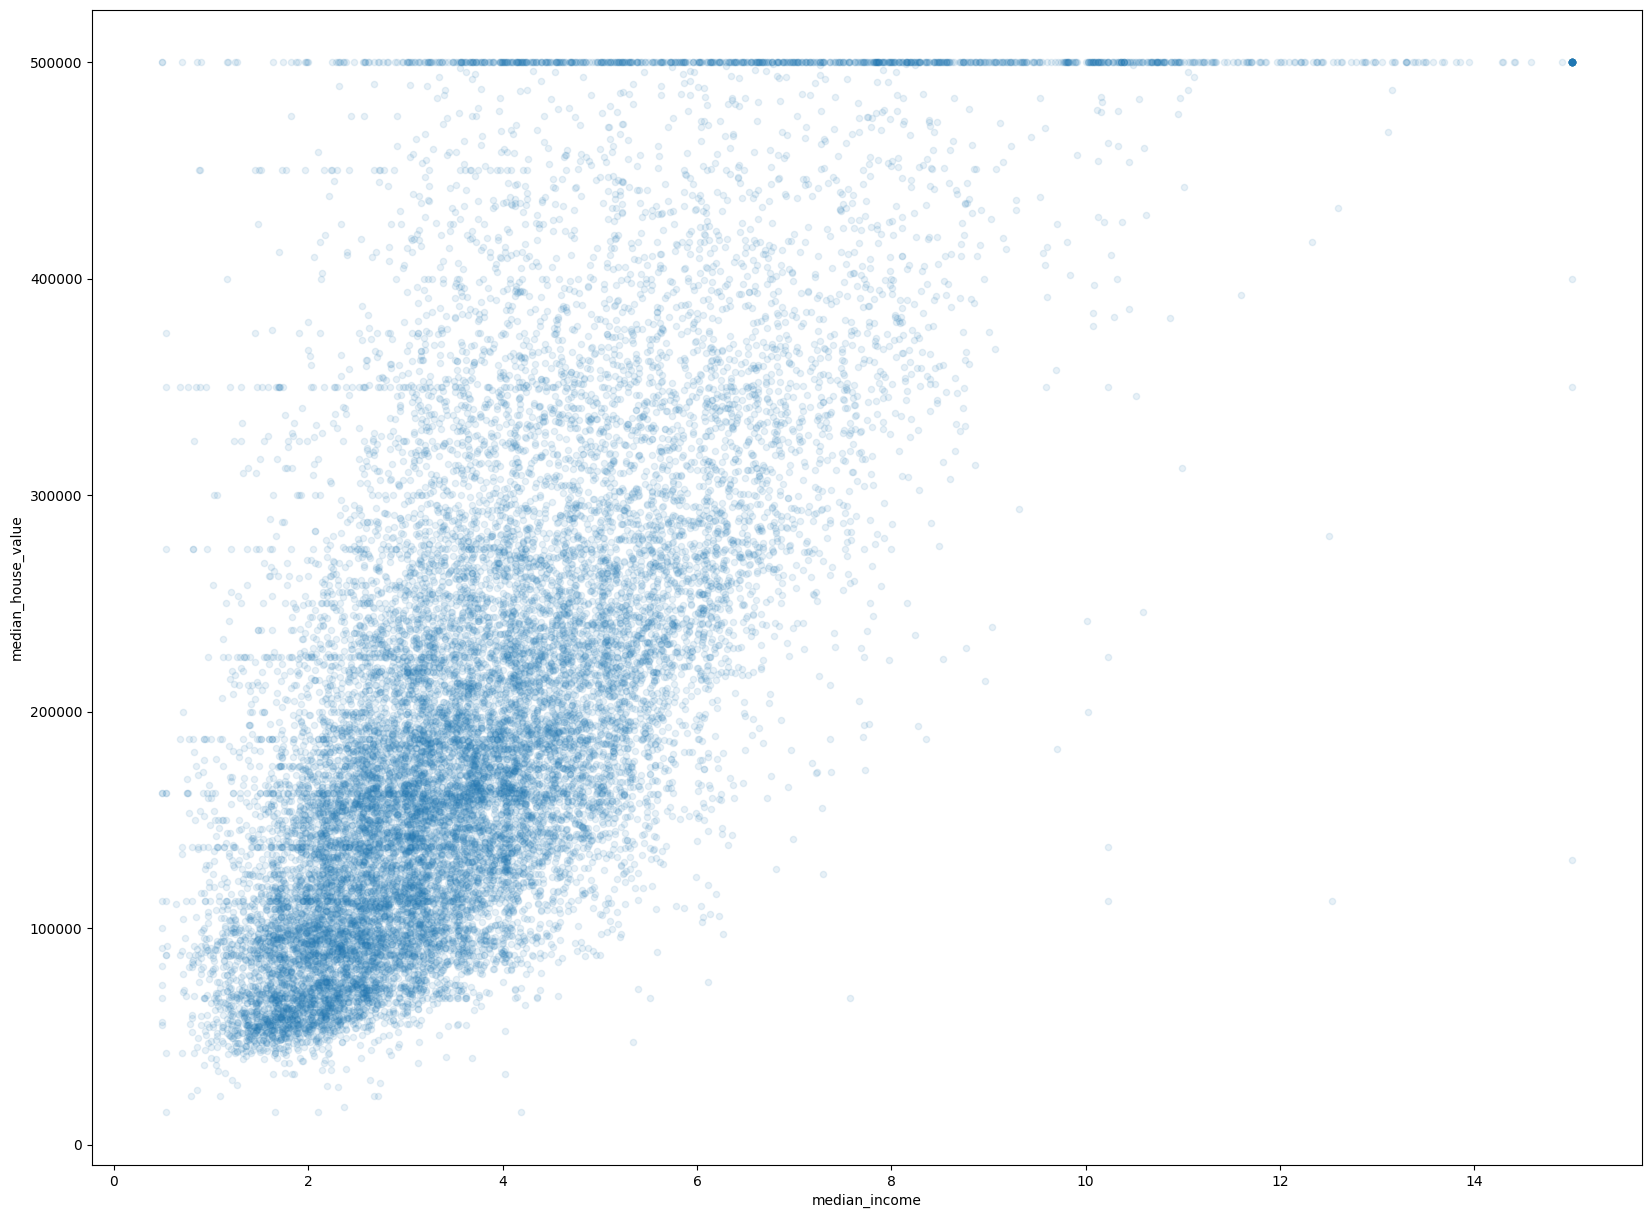

In [66]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",figsize=(20,15), alpha=0.1)

In [67]:
housing.drop_duplicates(inplace=True)
housing['rooms_by_household']=(housing['total_rooms']/housing['households'])
housing['bedrooms_per_rooms']=housing['total_bedrooms']/housing['total_rooms']
housing['population_per_household']=housing['population']/housing['households']


In [68]:
corr=housing.corr(numeric_only=True)
corr["total_bedrooms"].sort_values(ascending=True)

housing_median_age         -0.320451
latitude                   -0.066983
population_per_household   -0.028355
median_income              -0.007723
rooms_by_household          0.001538
median_house_value          0.049686
longitude                   0.069608
bedrooms_per_rooms          0.084238
population                  0.877747
total_rooms                 0.930380
households                  0.979728
total_bedrooms              1.000000
Name: total_bedrooms, dtype: float64

In [69]:
corr["households"].sort_values(ascending=True)

housing_median_age         -0.302916
rooms_by_household         -0.080598
latitude                   -0.071035
population_per_household   -0.027309
median_income               0.013033
longitude                   0.055310
bedrooms_per_rooms          0.065087
median_house_value          0.065843
population                  0.907222
total_rooms                 0.918484
total_bedrooms              0.979728
households                  1.000000
Name: households, dtype: float64

In [70]:
housing.drop(['total_bedrooms'],axis=1,inplace=True)

In [71]:
corr_matrix=housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=True)


bedrooms_per_rooms         -0.255880
latitude                   -0.144160
longitude                  -0.045967
population                 -0.024650
population_per_household   -0.023737
households                  0.065843
housing_median_age          0.105623
total_rooms                 0.134153
rooms_by_household          0.151948
median_income               0.688075
median_house_value          1.000000
Name: median_house_value, dtype: float64

we can conclude that the corrolation between the bedrooms_per_rooms and median_house_value is low in oposite to corrolation between rooms_by_household and median_house_value

In [72]:
x=housing.drop('median_house_value',axis=1)
y=housing["median_house_value"].to_numpy()
bins=np.linspace(y.min(),y.max(),100)
y_binned=np.digitize(y,bins)
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,shuffle=True,stratify=y_binned,random_state=22)
print("X_train",np.shape(X_train),'X_test',np.shape(X_test))  

X_train (16512, 11) X_test (4128, 11)


In [73]:
from sklearn.impute import SimpleImputer
inputer=SimpleImputer(strategy="mean")
inputer.fit_transform([[7,2,3],[4,np.nan,6],[10,5,9]])

array([[ 7. ,  2. ,  3. ],
       [ 4. ,  3.5,  6. ],
       [10. ,  5. ,  9. ]])

In [74]:
from sklearn.preprocessing import StandardScaler
data=np.random.randint(1,10,(3,3))
print(data) 

scaler=StandardScaler().fit(data)
print("\nmean",scaler.mean_)

data_scaled=scaler.transform(data)
print(data_scaled)
print("\nmean",data_scaled.mean(),"std=",data_scaled.std())

[[8 2 1]
 [1 9 4]
 [2 1 5]]

mean [3.66666667 4.         3.33333333]
[[ 1.40182605 -0.56195149 -1.37281295]
 [-0.86266219  1.40487872  0.39223227]
 [-0.53916387 -0.84292723  0.98058068]]

mean -3.700743415417188e-17 std= 1.0


In [75]:
from sklearn.preprocessing import OneHotEncoder
data=[["ROUGE"],["ROUGE"],["JAUNE"],["VERT"],["JAUNE"]]
encoder=OneHotEncoder().fit(data)
data_hot=encoder.transform(data).toarray()

print(data_hot)
print(encoder.categories_)
del data

[[0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
[array(['JAUNE', 'ROUGE', 'VERT'], dtype=object)]


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

num_feature=X_train.select_dtypes(include=[np.number]).columns
print(num_feature)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'population', 'households', 'median_income', 'rooms_by_household',
       'bedrooms_per_rooms', 'population_per_household'],
      dtype='object')


In [77]:
cat_feature=X_train.select_dtypes(include=[object]).columns
print(cat_feature)

Index(['ocean_proximity'], dtype='object')


In [78]:
num_pipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),
                       ("transform",PowerTransformer(method="yeo-johnson",standardize=True))])
full_pipeline=ColumnTransformer([("num",num_pipeline,num_feature),("cat",OneHotEncoder(),cat_feature)])
full_pipeline

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [79]:
print(full_pipeline)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('transform',
                                                  PowerTransformer())]),
                                 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'population', 'households', 'median_income', 'rooms_by_household',
       'bedrooms_per_rooms', 'population_per_household'],
      dtype='object')),
                                ('cat', OneHotEncoder(),
                                 Index(['ocean_proximity'], dtype='object'))])


In [80]:
full_pipeline = full_pipeline.fit(X_train)
X_train = full_pipeline.transform(X_train)
X_test = full_pipeline.transform(X_test)

print("\n X_train:", X_train.shape, " X_test:", X_test.shape)



 X_train: (16512, 15)  X_test: (4128, 15)


(Q15):we can conclude that after apply the preprocessing pipeline we have 15 features for bouth train dataset and test dataset
and we 16512 simples for train and 4128 for test

In [83]:
features=num_feature.to_numpy()
features=np.concatenate((features,['ocean_1','ocean_2','ocean_3',"ocean_4","ocean_5","median_house_value"]),axis=0)
print(features)

['longitude' 'latitude' 'housing_median_age' 'total_rooms' 'population'
 'households' 'median_income' 'rooms_by_household' 'bedrooms_per_rooms'
 'population_per_household' 'ocean_1' 'ocean_2' 'ocean_3' 'ocean_4'
 'ocean_5' 'median_house_value']


In [89]:
df_train = pd.DataFrame(np.concatenate((X_train, Y_train[:, np.newaxis]), axis=1), columns=features)
df_train.to_csv('housing_train.csv',index=False)
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,rooms_by_household,bedrooms_per_rooms,population_per_household,ocean_1,ocean_2,ocean_3,ocean_4,ocean_5,median_house_value
0,-1.249001e-15,0.872085,-0.821368,1.060025,0.762658,1.810501,0.078757,-1.545452,1.586059,-2.511716,1.0,0.0,0.0,0.0,0.0,240000.0
1,-1.221245e-15,0.861027,-0.652535,1.449561,1.413273,1.505998,0.637755,0.033086,-0.145523,-0.097845,1.0,0.0,0.0,0.0,0.0,250000.0
2,1.720846e-15,-1.372385,0.606412,-1.014326,-1.572720,-1.511673,-0.326826,1.523596,0.446924,-0.226179,0.0,1.0,0.0,0.0,0.0,134400.0
3,-1.276756e-15,0.890396,-0.243525,0.579703,0.367230,0.547590,0.833675,0.152906,-0.305407,-0.401924,1.0,0.0,0.0,0.0,0.0,287600.0
4,-1.942890e-16,0.660460,1.407146,-0.671688,-0.045275,-0.356063,-1.907712,-0.961195,1.693039,0.889069,0.0,1.0,0.0,0.0,0.0,49600.0


saving the prepared testing data set in data frame then in .csv

(Q16):

In [92]:
df_test=pd.DataFrame(np.concatenate((X_test,Y_test[:,np.newaxis]),axis=1),columns=features)
df_test.to_csv("housing_test.csv",index=False)
df_test.head()


,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,rooms_by_household,bedrooms_per_rooms,population_per_household,ocean_1,ocean_2,ocean_3,ocean_4,ocean_5,median_house_value
0,-1.942890e-16,0.684487,-0.736535,-0.482003,-0.302538,-0.120648,-1.726609,-1.045459,1.449302,-0.489332,0.0,1.0,0.0,0.0,0.0,47500.0
1,-1.387779e-16,-0.488552,-0.084404,0.830653,0.568589,0.908369,0.315645,-0.080219,0.010225,-0.783875,0.0,0.0,0.0,0.0,1.0,395100.0
2,-8.326673e-17,0.502611,0.755156,0.543519,0.211104,0.368740,-0.421444,0.490798,-0.537571,-0.359413,0.0,1.0,0.0,0.0,0.0,85500.0
3,-1.221245e-15,0.890396,1.758741,0.023673,0.003336,0.354319,-0.410195,-0.835306,0.926268,-0.921908,1.0,0.0,0.0,0.0,0.0,209500.0
4,5.828671e-16,-0.756126,-0.993752,-3.363676,-3.809716,-3.937836,1.732079,3.803370,-3.332458,1.515489,1.0,0.0,0.0,0.0,0.0,500001.0


(Q17): 

In [93]:
import joblib

joblib.dump(full_pipeline,'full_pipeline.pkl')

['full_pipeline.pkl']

In [94]:
loaded_pipline=joblib.load("full_pipeline.pkl")
print(loaded_pipline)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('transform',
                                                  PowerTransformer())]),
                                 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'population', 'households', 'median_income', 'rooms_by_household',
       'bedrooms_per_rooms', 'population_per_household'],
      dtype='object')),
                                ('cat', OneHotEncoder(),
                                 Index(['ocean_proximity'], dtype='object'))])
